# Lesson 3 : Color Spaces (RGB, Grayscale, HSV, LAB)

Color space understanding is **critical** for segmentation, enhancement, and medical image processing.

## What Is a Color Space?

A color space is a mathematical way to represent color as numbers.

Example:

A red pixel might be stored as:

```text
[255, 0, 0]
```
But that same red color can be represented differently in HSV or LAB.

Different color spaces highlight different properties:

* Brightness
* Color information
* Perception similarity
* Contrast

### RGB Color Space

RGB = Red, Green, Blue

Each pixel contains:

```text
(R, G, B)
```

Range:

* uint8 → 0–255
* float → 0–1

Example:

In [1]:
from skimage import data
img = data.astronaut()

print(img.shape)

(512, 512, 3)


![Image](https://upload.wikimedia.org/wikipedia/commons/5/56/RGB_channels_separation.png)

### Splitting RGB Channels

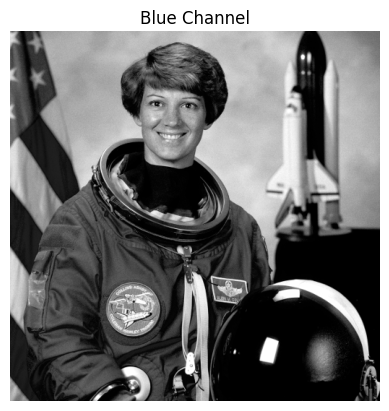

In [5]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

import matplotlib.pyplot as plt

plt.imshow(B, cmap='gray')
plt.title("Blue Channel")
plt.axis("off")
plt.show()

### Why RGB Is Not Always Ideal

Problem:

* RGB mixes brightness and color together
* Harder to segment based on lighting
* Sensitive to illumination changes

This is why we use other color spaces.

### Grayscale Conversion

Convert RGB → Grayscale:

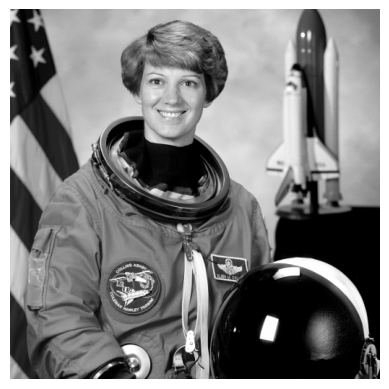

In [8]:
from skimage.color import rgb2gray

gray = rgb2gray(img)

plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

Formula internally:

```text
Gray = 0.2126R + 0.7152G + 0.0722B
```
Notice:

* Green has highest weight
* Human eye is most sensitive to green

### HSV Color Space
HSV = Hue, Saturation, Value
* Hue → Color type
* Saturation → Color intensity
* Value → Brightness

Convert:

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

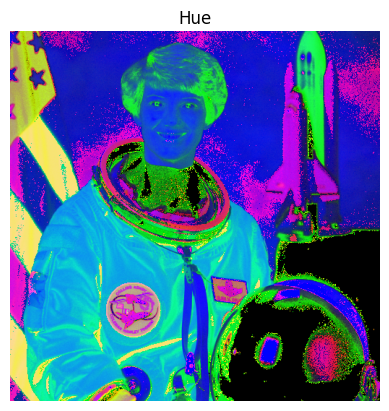

In [11]:
from skimage.color import rgb2hsv

hsv = rgb2hsv(img)

plt.imshow(hsv, cmap='hsv')
plt.title("Hue")
plt.axis("off")

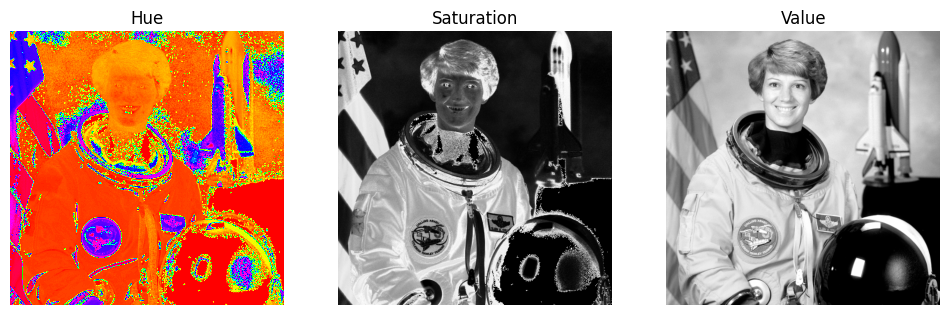

In [10]:
import matplotlib.pyplot as plt

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(H, cmap='hsv')
plt.title("Hue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(S, cmap='gray')
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap='gray')
plt.title("Value")
plt.axis("off")

plt.show()

### HSV Representation

![Image](https://images.openai.com/static-rsc-3/FdJaycYmXYPHcGZvadD2zJX5vhGyWJyyYUC2jNT2fixbv6CjPTmHRfBav-OJlmyUjX_mYQRbH1EOjmGfxqIAjbZFj5TOiGu-aZMHW0GXBls?purpose=fullsize\&v=1)

![Image](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Hsl-hsv_models.svg/330px-Hsl-hsv_models.svg.png)

![Image](https://www.researchgate.net/publication/343682169/figure/fig12/AS%3A941678017921047%401601524943761/The-demonstration-of-HSV-image-channel-separation-a-HSV-image-b-H-channel-image-c-S.png)

### Why HSV Is Useful

* Segment based on color (Hue)
* Separate brightness (Value)
* Good for color-based detection

Example use:

* Detect red lesions
* Detect bright regions

### LAB Color Space (Very Powerful)

LAB = L*, a*, b*

* L → Lightness
* a → Green ↔ Red
* b → Blue ↔ Yellow

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-51.966470632538474..100.0].


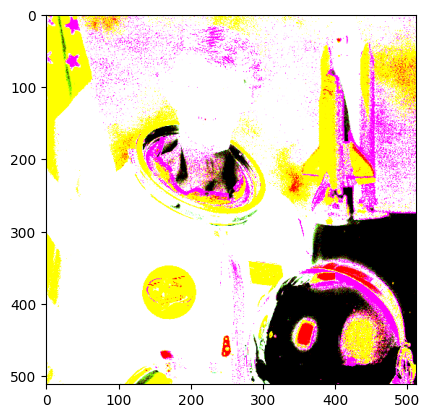

In [15]:
from skimage.color import rgb2lab

lab = rgb2lab(img)

plt.imshow(lab)
plt.show()

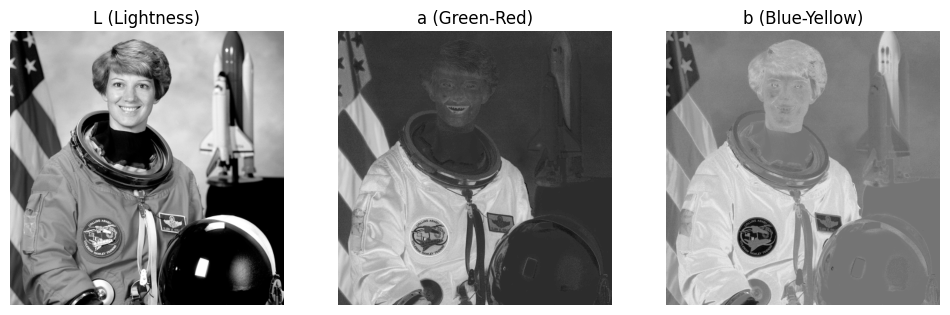

In [14]:
L = lab[:, :, 0]
a = lab[:, :, 1]
b = lab[:, :, 2]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(L, cmap='gray')
plt.title("L (Lightness)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(a, cmap='gray')
plt.title("a (Green-Red)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(b, cmap='gray')
plt.title("b (Blue-Yellow)")
plt.axis("off")

plt.show()

### LAB Color Model

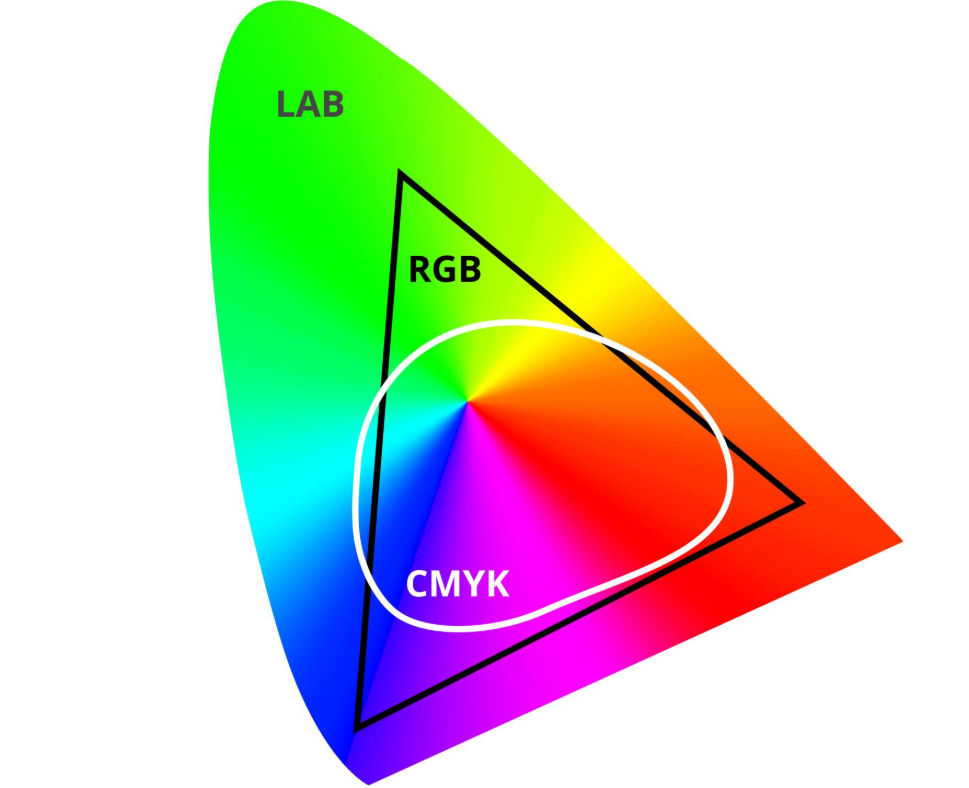

![Image](https://ars.els-cdn.com/content/image/3-s2.0-B9780081005293000074-f07-21-9780081005293.jpg)


### Why LAB Is Important

* Designed to match human perception
* Better for color-based segmentation
* More stable under lighting variation

Used in:

* Medical imaging
* Color clustering
* Research papers


### Color Space Comparison

| Color Space | Best For                           |
| ----------- | ---------------------------------- |
| RGB         | Display                            |
| Grayscale   | Edge detection                     |
| HSV         | Color-based segmentation           |
| LAB         | Advanced segmentation & clustering |